节点数: 13
边数: 7


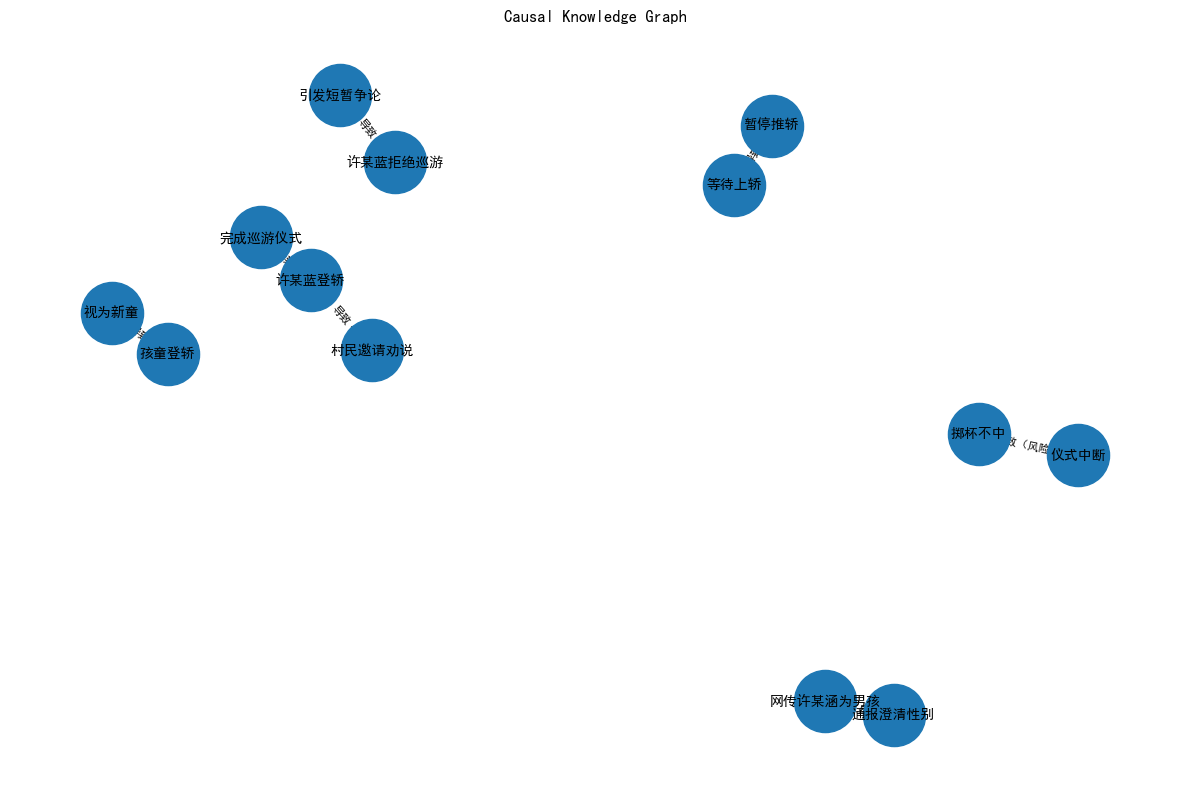

In [4]:
import json
import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] 

def load_triples(filepath="all_triples.json"):
    with open(filepath, "r", encoding="utf-8") as f:
        return json.load(f)


def build_graph(all_results):
    """
    构建有向因果图
    cause -> effect
    """
    G = nx.DiGraph()

    for filename, triples in all_results.items():
        for triple in triples:
            cause = triple["cause"]
            relation = triple["relationship_type"]
            effect = triple["effect"]

            # 添加节点
            G.add_node(cause)
            G.add_node(effect)

            # 添加带关系属性的边
            G.add_edge(cause, effect, label=relation)

    return G


def draw_graph(G):
    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(G, seed=42)

    # 画节点
    nx.draw_networkx_nodes(G, pos, node_size=2000)

    # 画边
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)

    # 画标签
    nx.draw_networkx_labels(G, pos, font_size=10)

    # 画边标签
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Causal Knowledge Graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    data = load_triples("all_triples.json")
    G = build_graph(data)

    print(f"节点数: {G.number_of_nodes()}")
    print(f"边数: {G.number_of_edges()}")

    draw_graph(G)